# ဒေတာ ကြိုတင်ပြင်ဆင်ခြင်း (Data Preprocessing)
ဒေတာများ ကောက်ယူပြီး အမည်တံဆိပ်ကပ်ခြင်း (Labeling) လုပ်ငန်းစဉ် ပြီးဆုံးပါက၊
ဒေတာများကို ကြိုတင်ပြင်ဆင်ခြင်း (Preprocessing)၊ ခွဲခြမ်းစိတ်ဖြာခြင်း (Analysis)၊ သန့်စင်ခြင်း (Cleaning) နှင့် လိုအပ်ပါက အမျိုးအစား/အတန်းအစားအလိုက် ဒေတာပမာဏ ညီညွတ်အောင်ပြုလုပ်ခြင်း (Class Balancing) တို့ကို ဆောင်ရွက်ရမည် ဖြစ်သည်။ ဤလုပ်ငန်းစဉ်တွင် စာသားများကို အစိတ်အပိုင်းများအဖြစ် ပိုင်းခြားခြင်း (Tokenization)၊ ဂဏန်းများအဖြစ် ပြောင်းလဲခြင်း (Numericalization) နှင့် ဖိုင်တစ်ခုချင်းစီအလိုက် သိမ်းဆည်းခြင်းများကို လုပ်ဆောင်သွားမည် ဖြစ်သည်။

---

## လုပ်ငန်းစဉ် အဆင့်ဆင့် (Process Flow)

1. ဒေတာများကို စနစ်ထဲသို့ ထည့်သွင်းခြင်း (Load Data) <br>
2. ဒေတာများကိုခြမ်းစိတ်ဖြာ လေ့လာခြင်း (Exploratory Data Analysis) <br>
3. ဒေတာများကို ကြိုတင်ပြင်ဆင်ခြင်း (Data Preprocessing) <br>
4. စာသားများကို အစိတ်အပိုင်းများအဖြစ် ပိုင်းခြားခြင်း (Tokenization) <br>
5. ဂဏန်းများအဖြစ် ပြောင်းလဲခြင်း (Numericalization) <br>

## ၁။ ဒေတာများကို စနစ်ထဲသို့ ထည့်သွင်းခြင်း (Load Data)

In [ ]:
# import required libraries
import re
import os
import gspread
import unicodedata
import numpy as np
import pandas as pd
from google.colab import auth
import matplotlib.pyplot as plt
from google.auth import default

In [ ]:
# mout drive to access the data in the shared drive
# you will need to provide your credentials to google
# connect to drive and click on "continue"
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# define the path to the shared folder shortcut in your My Drive
# Note: Ensure the folder name matches exactly what is in your Drive
shared_folder_path = '/content/drive/MyDrive/AI - Week 1 - Group 2 - NLP Project'

# path to the specific 'data' folder
data_folder = os.path.join(shared_folder_path, 'data/raw_data')

# list files to verify connection
# print("Files in data folder:", os.listdir(data_folder))

In [ ]:
import os

target_directory = '/content/drive/MyDrive/AI - Week 1 - Group 2 - NLP Project/data/final_data'
os.makedirs(target_directory, exist_ok=True) # Ensure the target directory exists
os.chdir(target_directory)

print(f"Current working directory changed to: {os.getcwd()}")

Current working directory changed to: /content/drive/.shortcut-targets-by-id/1h28_ttOubDtU_aD0lo08qmozw43mIvXy/AI - Week 1 - Group 2 - NLP Project/data/final_data


In [ ]:
# authenticate to Google Sheets
auth.authenticate_user()
creds, _ = default()
gc = gspread.authorize(creds)

# open the sheet by its name (make sure the name matches exactly)
# Note: You don't need the full file path here, just the document name
spreadsheet = gc.open('Combined')
worksheet = spreadsheet.get_worksheet(0) # Gets the first tab

# convert to Pandas DataFrame
data = pd.DataFrame(worksheet.get_all_records())

## ၂။ ဒေတာများကိုခွဲခြမ်းစိတ်ဖြာ လေ့လာခြင်း (Exploratory Data Analysis)

In [ ]:
# check no of smaples and columns
print("Before", data.shape)

Before (1507, 2)


ဒီ Code ဟာ မြန်မာစာသား (Burmese Text) တွေကို Data Processing မလုပ်ခင်မှာ သန့်စင်ပေးဖို့ (Clean လုပ်ဖို့) ရေးထားတာ ဖြစ်ပါတယ်။ အဓိက လုပ်ဆောင်ချက်တွေကတော့ -

Unicode Normalization
___
မြန်မာစာ ရိုက်တဲ့အခါ တချို့ စာလုံးတွေက မြင်ရတာ တူပေမယ့် Unicode Code မတူတာမျိုး ရှိတတ်ပါတယ်။ (ဥပမာ - အသတ် နဲ့ အောက်ကမြစ် ဘယ်ဟာ အရင်ရိုက်သလဲ စသဖြင့်)။ NFC ကို သုံးပြီး စာသားအားလုံးကို စံနှုန်းတစ်ခုထဲဖြစ်အောင် ညှိပေးတာပါ။

Invisible Characters ဖယ်ရှားခြင်း
___
စာသားထဲမှာ မျက်စိနဲ့မမြင်ရတဲ့ Zero-width space (\u200b) တွေ၊ hidden characters တွေကို ဖယ်ထုတ်ပေးပါတယ်။ ဒီအက္ခရာတွေက စာသားရှာဖွေတဲ့အခါ (Searching) ဒါမှမဟုတ် AI Model တွေထဲ ထည့်တဲ့အခါ အမှားအယွင်း ဖြစ်စေနိုင်လို့ပါ။

Space များ ရှင်းထုတ်ခြင်း
___
စာကြောင်းထဲမှာ မလိုအပ်ဘဲ ပါနေတဲ့ Space အပိုတွေ၊ Tab တွေနဲ့ Newline တွေကို Space တစ်ခုတည်းဖြစ်အောင် လုပ်ပေးပြီး စာကြောင်းရဲ့ အရှေ့နဲ့ အနောက်က Space တွေကို ဖြတ်ထုတ်ပေးပါတယ်။

အတိုချုပ်ပြောရရင် ဒီ Code ဟာ ဒေတာတွေ ပိုမိုတိကျစေဖို့နဲ့ စာသားတွေကို ပုံစံတကျ ဖြစ်စေဖို့အတွက် အသုံးပြုတာ ဖြစ်ပါတယ်။

In [ ]:
def normalize_burmese_text(text):
    """
    A normalization function to standardize to Unicode get rid of ghost-chrracter and white-spaces
    """
    # handle null or empty values to avoid errors
    if pd.isna(text):
        return text

    # ensure the input is treated as a string
    text = str(text)

    # standardize Unicode (NFC) so different typing methods match
    text = unicodedata.normalize("NFC", text)

    # remove invisible 'ghost' characters (Zero-width spaces, etc.)
    # these often cause issues in text searching or machine learning
    text = re.sub(r"[\u200b\u200c\u200d\ufeff]", "", text)

    # replace multiple spaces/newlines with a single space and trim edges
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
#apply the function to the 'text' column
data["text"] = data["text"].apply(normalize_burmese_text)

In [ ]:
# check the data duplication
# count the no. of duplicated
total_duplicates = data.duplicated(subset=['text']).sum()
print(f"There are {total_duplicates} duplicate rows in the dataset.")

There are 12 duplicate rows in the dataset.


In [ ]:
# returns a Boolean (True/False) for every row
duplicate_mask = data.duplicated(subset=['text'], keep=False)
#creates a new DataFrame containing ONLY the duplicate rows
duplicates_df = data[duplicate_mask].sort_values(by='text')
display(duplicates_df.head(10))

,text,label
676,ကျေးဇူး ညီမလေး သက်သာတယ် ခုတော့,1
636,ကျေးဇူး ညီမလေး သက်သာတယ် ခုတော့,1
1481,ကြောက်စရာကြီး,4
298,ကြောက်စရာကြီး,4
588,ချစ်ခင်လေးစားရတဲ့မိသားစုလေး,1
591,ချစ်ခင်လေးစားရတဲ့မိသားစုလေး,1
850,ချစ်စရာလေး,2
491,ချစ်စရာလေး,2
494,ချစ်လိုက်တာ,2
367,ချစ်လိုက်တာ,2


In [ ]:
# remove duplicated data
# keep='first' means we keep the first occurrence and delete the rest
data = data.drop_duplicates(subset=["text"], keep="first")

In [ ]:
# check no of smaples and columns to sure the duplciated data are gone
print("After", data.shape)

After (1495, 2)


In [ ]:
# check the firt 5 rows of the dataframe
data.head(5)

,text,label
0,ကမ်းလှမ်းချက်ကို ဝမ်းမြောက်ဝမ်းသာ လက်ခံပါတယ်,1
1,အဆင်ပြေအေးချမ်းပါစေ,2
2,သူမ ကြောက်လွန်းလို့ ဒူးတွေတုန်နေတယ်,4
3,အရမ်းကျေနပ်ပါတယ်ဗျ,1
4,ဖြစ်လိုရာဖြစ်ပါစေကွယ်,2


In [ ]:
# check the last 5 rows of the dataframe
data.tail(5)

,text,label
1502,ဒါမျိုးတစ်ခါမှမကြုံဖူးဘူး,5
1503,ဟယ် ထင်မထားဘူး,5
1504,ဒီလိုကြီးမှန်း မသိခဲ့ဘူး,5
1505,သိလိုက်ရတာ တစ်မျိုးကြီးပဲ,5
1506,ဘယ်လိုတောင်ဖြစ်ရတာလဲ,5


In [ ]:
data["text"].head(5)

,text
0,ကမ်းလှမ်းချက်ကို ဝမ်းမြောက်ဝမ်းသာ လက်ခံပါတယ်
1,အဆင်ပြေအေးချမ်းပါစေ
2,သူမ ကြောက်လွန်းလို့ ဒူးတွေတုန်နေတယ်
3,အရမ်းကျေနပ်ပါတယ်ဗျ
4,ဖြစ်လိုရာဖြစ်ပါစေကွယ်


In [ ]:
data["label"].head(5)

,label
0,1
1,2
2,4
3,1
4,2


In [ ]:
# information
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1495 entries, 0 to 1506
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1495 non-null   object
 1   label   1495 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 35.0+ KB


In [ ]:
# basic statistic of the data
# data distribution
data.describe()

,label
count,1495.000000
mean,2.226087
std,1.622215
min,0.000000
25%,1.000000
50%,2.000000
75%,3.000000
max,5.000000


### ၂(က)။ Labeling Reference

ကျွန်ုပ်တို့၏ Analysisအရ လက်ရှိ dataset ထဲတွင်

- 0: ဝမ်းနည်းခြင်း (Sadness)
- 1: ပျော်ရွှင်ခြင်း (Joy)
- 2: ချစ်ခြင်း (Love)
- 3: ဒေါသထွက်ခြင်း (Angry)
- 4: ကြောက်ရွံ့ခြင်း (Fear)
- 5: အံ့သြခြင်း (Surprise)

ရှိပါတယ်

In [ ]:
# class distribution
data["label"].value_counts().sort_index()

,count
label,
0,257
1,358
2,202
3,320
4,184
5,174


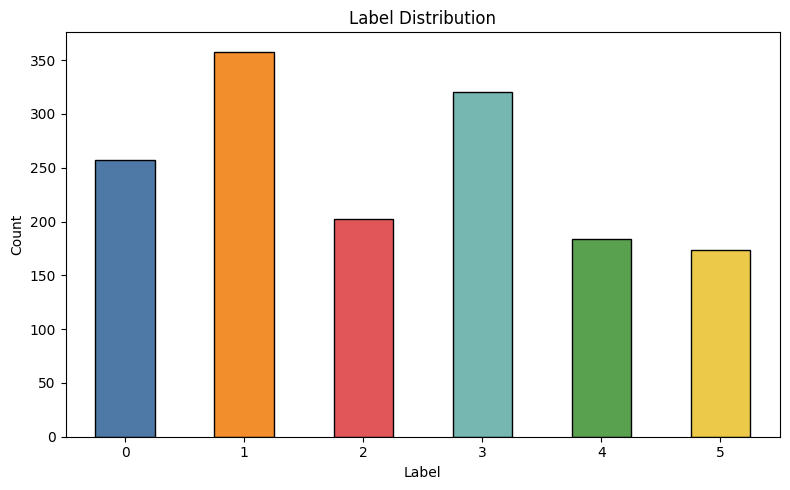

In [ ]:
# visualization of class distribution
label_counts = data["label"].value_counts().sort_index()
# Custom 6-color list
cat_colors = ["#4e79a7", "#f28e2c", "#e15759", "#76b7b2", "#59a14f", "#edc949"]
ax = label_counts.plot(kind="bar", figsize=(8, 5), color=cat_colors, edgecolor="black")
ax.set_title("Label Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_xticklabels(label_counts.index.astype(str), rotation=0)
plt.tight_layout()
plt.show()

### ၂(ခ)။ တွေ့ရှိချက်များ (Findings)

ကျွန်ုပ်တို့၏ Analysisအရ လက်ရှိ dataset ထဲတွင်

- ဝမ်းနည်းခြင်း (Sadness) ၂၃၇ ခု၊
- ပျော်ရွှင်ခြင်း (Joy) ၃၄၁ ခု၊
- ချစ်ခြင်း (Love) ၁၈၁ ခု၊
- ဒေါသထွက်ခြင်း (Angry) ၃၀၁ ခု၊
- ကြောက်ရွံ့ခြင်း (Fear) ၁၆၆ ခု နှင့်
- အံ့သြခြင်း (Surprise) ၁၅၄ခု

စုစုပေါင်း နမူနာဒေတာ (samples) များ ရှိနေပါသည်။

Class များအကြား ဒေတာပမာဏ မမျှတမှု (Imbalance) အနည်းငယ်ရှိနေသော်လည်း ၎င်းသည် SMOTE ကဲ့သို့ ပြင်းထန်သော နည်းလမ်းများကို သုံးရန်လိုအပ်သည်အထိ ဆိုးရွားခြင်းမရှိပါ။ အများဆုံး class ဖြစ်သော Joy တွင် sample ၃၄၁ ခုရှိပြီး အနည်းဆုံး class ဖြစ်သော Surprise တွင် ၁၅၄ ခု ရှိသောကြောင့် အချိုးအစားမှာ ၂.၂ ဆ နှင့် ၁ ဆ ခန့် ရှိပါသည်။ ဤကဲ့သို့ မမျှတမှုအဆင့်မှာ အသင့်အတင့် (moderate) သာဖြစ်ပြီး Model ၏ စွမ်းဆောင်ရည်အပေါ် အနည်းငယ် သက်ရောက်မှုရှိနိုင်သော်လည်း ရှုပ်ထွေးသော resampling နည်းလမ်းများကို သုံးရန် မလိုအပ်ပါ။ ထိုသို့သောအခြေအနေမျိုးတွင် အခြေခံ baseline model တစ်ခုကို အရင်ဆုံး train ကြည့်ပြီး မမျှတမှုကြောင့် စွမ်းဆောင်ရည်ကို အမှန်တကယ် ထိခိုက်မှုရှိမရှိ လေ့လာခြင်းက ပိုမိုသင့်တော်ပါသည်။ အထူးသဖြင့် Accuracy ထက် macro F1-score ကဲ့သို့သော evaluation metric များကို အသုံးပြုသည့်အခါတွင် ပိုမိုသိသာနိုင်ပါသည်။

---

### ၂(ဂ)။ ဒေတာပမာဏ မမျှတမှုကို ဖြေရှင်းခြင်း (Addressing Class Imbalance)

- ### SMOTE

  - NLP လုပ်ငန်းစဉ်များတွင် SMOTE ကို အသုံးပြုရန် ယေဘုယျအားဖြင့် အကြံမပြုပါ။ အကြောင်းမှာ SMOTE သည် numerical feature space ပေါ်တွင်သာ အလုပ်လုပ်ပြီး ရှိရင်းစွဲ ဒေတာများကြား ဖြည့်စွက်တွက်ချက်ခြင်းဖြင့် ဒေတာအတု (synthetic samples) များကို ဖန်တီးပေးသောကြောင့် ဖြစ်ပါသည်။ စာသားဒေတာ (text data) များအတွက် TF-IDF သို့မဟုတ် embeddings ကဲ့သို့သော ကိုယ်စားပြုမှုများကို အသုံးပြုသည့်အခါ ထိုကဲ့သို့ **ဖန်တီးလိုက်သော ဒေတာအတုများသည် အဓိပ္ပာယ်ရှိသော သို့မဟုတ် မှန်ကန်သော စာကြောင်းများ ဖြစ်မလာနိုင်ဘဲ ဒေတာ၏ semantic structure (အနက်အဓိပ္ပာယ် တည်ဆောက်ပုံ) ကို ပျက်ယွင်းစေနိုင်ပါသည်။** ရလဒ်အနေဖြင့် **SMOTE ကို အသုံးပြုခြင်းသည် စွမ်းဆောင်ရည်ကို တိုးတက်စေမည့်အစား တစ်ခါတစ်ရံတွင် ပိုမိုဆိုးရွားသွားစေနိုင်ပါသည်။**

  - ထို့ကြောင့် NLP အတွက် ပိုမိုသင့်တော်သော နည်းလမ်းများမှာ class weights များကို ညှိယူခြင်း၊ data augmentation ပြုလုပ်ခြင်း သို့မဟုတ် ရိုးရှင်းသော resampling နည်းလမ်းများကို အသုံးပြုခြင်းတို့ ဖြစ်ပါသည်။

- ### Class Weighting

  - ဤအခြေအနေအတွက် **Class weighting သည် အထိရောက်ဆုံးနှင့် အရှင်းလင်းဆုံး ချဉ်းကပ်မှုတစ်ခု ဖြစ်ပါသည်။** အရေအတွက်နည်းသော Surprise နှင့် Angry ကဲ့သို့သော class များကို ပိုမိုအရေးကြီးကြောင်း သတ်မှတ်ပေးခြင်းဖြင့် မူလဒေတာဖြန့်ကြက်မှု (data distribution) ကို မပြောင်းလဲစေဘဲ Training ပြုလုပ်စဉ်အတွင်း Model က ၎င်းတို့ကို ပိုမိုအာရုံစိုက်လာစေရန် တွန်းအားပေးနိုင်ပါသည်။ ဤနည်းလမ်းသည် Logistic Regression၊ SVM သို့မဟုတ် BERT ကဲ့သို့သော Deep Learning model များအတွက် အထူးသင့်လျော်ပါသည်။

  - ထို့အပြင် စာသားများအတွက် သီးသန့်ဖန်တီးထားသော synonym replacement (အဓိပ္ပာယ်တူစာလုံး အစားထိုးခြင်း) သို့မဟုတ် back translation (ပြန်လည်ဘာသာပြန်ခြင်း) ကဲ့သို့သော data augmentation နည်းလမ်းများကို အသုံးပြု၍ အနက်အဓိပ္ပာယ်ကို မပျက်စေဘဲ နည်းပါးနေသော class များ၏ ဒေတာပမာဏကို တိုးမြှင့်နိုင်ပါသည်။

- ### Sampling

  - အခြားလက်တွေ့ကျသော ချဉ်းကပ်မှုတစ်ခုမှာ ရိုးရှင်းသော oversampling သို့မဟုတ် undersampling ကို အသုံးပြုခြင်း ဖြစ်ပါသည်။ ဥပမာအားဖြင့် ဒေတာမျှတစေရန် နည်းပါးသော class များကို ပွားယူခြင်း သို့မဟုတ် အများဆုံးဖြစ်နေသော class ကို အနည်းငယ် လျှော့ချခြင်းတို့ ပြုလုပ်နိုင်ပါသည်။ ဤနည်းလမ်းများသည် နည်းပညာအရ သိပ်မမြင့်မားသော်လည်း စာသားဒေတာများအတွက် SMOTE ကဲ့သို့ အတုဖန်တီးသော နည်းလမ်းများထက် ပိုမိုထိရောက်ပြီး ဘေးကင်းပါသည်။

  - ထို့အပြင် imbalanced settings (ဒေတာမမျှတမှုရှိသော အခြေအနေ) များတွင် Accuracy တစ်ခုတည်းမှာ မှားယွင်းသော ကောက်ချက်ကို ပေးနိုင်သောကြောင့် macro F1-score၊ precision နှင့် recall စသည့် သင့်လျော်သော metric များဖြင့် model ကို အကဲဖြတ်ရန် အရေးကြီးပါသည်။ ကျွန်ုပ်အနေဖြင့် Undersampling ပြုလုပ်ရန် အကြံပြုလိုပါသည်။

In [ ]:
import os
print(os.getcwd())

/content/drive/.shortcut-targets-by-id/1h28_ttOubDtU_aD0lo08qmozw43mIvXy/AI - Week 1 - Group 2 - NLP Project/data/final_data


In [ ]:
# save data before downsampling
# the current working directory is already /content/drive/MyDrive/AI - Week 1 - Group 2 - NLP Project/data/final_data
# so, we just need to specify the filename
before_downsampling_filename = 'data_before_downsampling.csv'
data.to_csv(before_downsampling_filename, index=False)

print(f"Saved original dataset to: {before_downsampling_filename}")
print(f"Shape: {data.shape}")

Saved original dataset to: data_before_downsampling.csv
Shape: (1495, 2)


In [ ]:
# save data after downsampling

# find the minimum class count for undersampling
min_class_count = data['label'].value_counts().min()

# group data by label and apply random sampling to achieve undersampling
df_downsampled = data.groupby('label').apply(lambda x: x.sample(min_class_count)).reset_index(drop=True)

# display the new class distribution and shape
print("Class distribution after downsampling:")
print(df_downsampled['label'].value_counts().sort_index())
print(f"Shape after downsampling: {df_downsampled.shape}")

# save the downsampled data to a CSV file directly in the current working directory
after_downsampling_filename = 'data_after_downsampling.csv'
df_downsampled.to_csv(after_downsampling_filename, index=False)

Class distribution after downsampling:
label
0    174
1    174
2    174
3    174
4    174
5    174
Name: count, dtype: int64
Shape after downsampling: (1044, 2)


/tmp/ipykernel_18147/3884002235.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_downsampled = data.groupby('label').apply(lambda x: x.sample(min_class_count)).reset_index(drop=True)
